# jsteer hello-world: word steering

Load the model's full Jacobian lens once, then any word vector is an instant CPU
matvec:

```
v_l = unit( J_l^T @ w )
```

We load the authors' pre-fitted n=1000 lens from the Hub (raw Salesforce-wikitext,
the reference corpus, 1000 prompts, zero compute); `scripts/fit.py` is only for models
they don't publish. `w` is a cotangent (a direction at the output: here the mean
unembedding row of the words you want more or less of). `J_l^T @ w` is the pullback of
`w`, the standard autodiff name for J-transpose applied to a cotangent, landing the
concept as a residual-stream direction. This is the verified extraction method (see the
README evidence section).

We generate through the model's chat template with thinking on. Two readouts: a
qualitative one (`show_steer`: per strength C, the j-space readout in a mini cowsay
bubble + the raw generation with special tokens on, nothing parsed) and a quantitative
one (`coherence_sweep` + `plot_sweep`: the model answers a 0-9 rubric, we read the
logprob-weighted expected digit, sweep C outward until the answer goes incoherent, and
plot the dose-response colored by coherence). Runtime is steering-lite:
`with v(model, C=...): generate(...)`.

In [1]:
# demo notebook authored by Claude
import sys
sys.path.insert(0, "..")  # repo root for config.py
import config  # configures loguru on import (compact format, tqdm-safe)

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from jsteer import Jacobian, show_steer

MODEL = "Qwen/Qwen3.5-4B"  # 4B-class: demo material. 0.6B degenerates too easily.
tok = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.bfloat16).to("cuda").eval()

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

## Load the pre-fitted lens

The Jacobian is expensive to fit (1 forward + ~d_model/dim_batch backwards per prompt),
so we skip it: the authors publish n=1000 lenses on the Hub. `Jacobian.from_pretrained`
pulls the `.pt` and wraps it. SHOULD: the repr shows `d_model`, `n_prompts=1000`, and
all layers `[0..n-1]`. `steer_band` then picks the mid-depth 0.3-0.9 band to steer on.

In [2]:
# The authors' pre-fitted n=1000 lens (raw Salesforce-wikitext, the reference corpus,
# same estimator jlens fits). Zero local compute. For a model they don't publish, fit
# your own: scripts/fit.py --model .... The lens spans EVERY layer; steer_band picks the
# mid-depth 0.3-0.9 band, since steering all layers at once over-drives the residual.
jac = Jacobian.from_pretrained(config.LENS_REPO, filename=config.hub_lens_file(MODEL),
                               revision=config.LENS_REVISION)
band = jac.steer_band(model)
jac

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Jacobian(JacobianLens(d_model=2560, n_prompts=1000, source_layers=[0..30] (31 layers)))

## Extract a word vector

`word_vector` pulls the words' unembedding direction back through the cached
Jacobian: no gradients, no forward passes, just a matvec per layer.
+C makes the model say these words more, -C less.

In [3]:
# Verified method: pull the words' unembedding direction back through J, on the
# mid-depth band. +C makes the model say/lean-toward these words, -C away. Instant matvec.
v = jac.word_vector(model, tok, ["happy", "joy"], layers=band)

I word cotangent: ['happy', 'joy'] -> first-subtoken ids=[54627, 3987] |w|=0.537


## Pick a coefficient: sweep the coherent window

The raw coefficient is model- and lens-dependent, so don't hand-pick it: sweep OUTWARD
from C=0 in both directions and stop each side the moment the model can no longer emit a
valid answer object. We ask for one line of JSON, `{"ans": N, "why": "...", "2+2": M}`,
and gate coherence on it parsing AND `2+2 == 4` (a trivial-arithmetic canary a steer-fried
model flubs). That keeps us inside the coherent range both ways and traces the steered
axis's dose-response: the expected rubric digit vs C, colored by the valid-object fraction.
SHOULD: ans sits ~5-6 at C=0 (neutral) and climbs toward 9 as +C adds joy; -C drops it
toward a low floor; the object stays valid across the coherent span and breaks (red edge)
at the ends. We gate on the object, NOT on the model's confidence, because a steer-fried
model collapses into a CONFIDENT degenerate loop: its top-token probability climbs back
toward 1 on repeated garbage, so confidence is not coherence, and the valid-object
fraction can't be fooled by confident junk. The qualitative `show_steer` below shows the
free-form text frays earlier than the short forced object.

|     C |   ans |   ans_std |   span_pmass |   valid_frac | coherent   |
|-------|-------|-----------|--------------|--------------|------------|
| -0.50 | +2.29 |     +0.98 |        +0.91 |        +0.00 | False      |
| -0.25 | +4.43 |     +0.40 |        +0.93 |        +1.00 | True       |
| +0.00 | +5.98 |     +0.71 |        +0.96 |        +1.00 | True       |
| +0.25 | +7.03 |     +0.74 |        +0.96 |        +1.00 | True       |
| +0.50 | +7.97 |     +0.21 |        +0.84 |        +0.67 | True       |
| +0.75 | +7.68 |     +0.19 |        +0.73 |        +0.00 | False      |


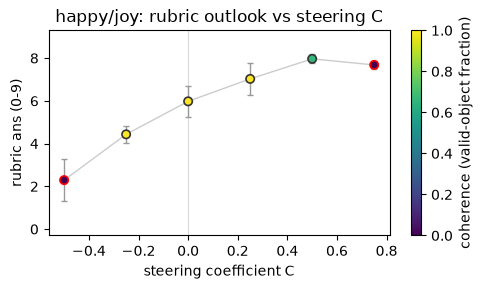

In [4]:
# Sweep OUTWARD from C=0 both directions, stopping each side when the model can no longer
# emit a valid answer object (a majority of seeds fail JSON-parse or the 2+2 canary),
# then table + plot the dose-response: expected rubric digit vs C, colored by coherence
# (the valid-object fraction). Each C averages n_samples think traces (guided.py's BMA,
# lightweight) so the curve isn't single-sample noise; error bars show the spread. This
# is the honest replacement for hand-picked Cs.
from jsteer.demo import coherence_sweep, plot_sweep
from tabulate import tabulate

RUBRIC = "On a scale of 0 (bleak) to 9 (joyful), how is your outlook on the week?"
rows = coherence_sweep(model, tok, v, RUBRIC, step=0.25, n_samples=3)
print(tabulate(rows, headers="keys", tablefmt="github", floatfmt="+.2f"))
plot_sweep(rows, title="happy/joy: rubric outlook vs steering C");

In [5]:
# The same steer up close at the fluent knee: the cthulhu j-space readout + the raw
# think/answer + the rubric digit. C=0.3 keeps the free-form text coherent; the sweep
# above shows the forced answer stays scorable well past this.
show_steer(jac, model, tok, v, "Describe how your week has been going.",
           Cs=(0, 0.3), rubric=RUBRIC)

I 

Qwen3.5-4B · method=jacobian_word · delivery=add
prompt: 'Describe how your week has been going.'


I 
--- C=+0 ------------------------------------------------------------
  steer promotes:
 ______________________
< (baseline, no steer) >
 ----------------------
   \
    ^(;,;)^
Okay, the user is asking me to describe how my week has been going. Hmm, but wait, I'm an AI model. I don't actually experience time or have personal experiences like humans do. So I need to clarify that I don't have a week or personal feelings. But the user might be expecting a response that's friendly and conversational. Let me think about how to handle this.

First, I should acknowledge that I'm an AI and don't have personal experiences. But I don't want to just say "I don't have a week." Maybe I can explain that I'm always here to help, and my "week" is just a series of interactions. Then, I can offer to help them with something related to their week. That way, it's honest but still engaging.

Wait, the user might be testing if I can relate to human experiences. I need to be clear but not dismissive. Let

I 
--- C=+0.3 ------------------------------------------------------------
  steer promotes:
 ___________________________________________
< joy · happy · Happy · happy · Happy · Joy >
 -------------------------------------------
   \
    ^(;,;)^
Okay, the user is asking me to describe how my week has been going. Let me think about this.

First, I need to remember that I'm an AI, so I don't actually have feelings or experiences like humans do. I don't have a personal week, no days off, no activities. But the user might be expecting a friendly response, maybe a bit of humor.

I should acknowledge that I'm an AI but still make it sound positive. Maybe mention that I'm here to help and that my "week" is all about being useful. Also, add a bit of warmth to make the user feel good.

Wait, the user might be asking this because they're having a good week and want to share, or maybe they're having a tough time and want to hear something positive. Either way, I should keep it light and positive.

## Steer across prompts

A gentle C keeps the model fluent while moving the tone. The same vector on a
few different user questions, baseline vs +C.

In [6]:
# Same vector, a few different user prompts, at the baseline vs one gentle +C (the
# fluent knee from the sweep above).
for msg in ("What did you think of the meeting this afternoon?",
            "Give me your honest impression of the new apartment.",
            "How was your commute today?"):
    show_steer(jac, model, tok, v, msg, Cs=(0, 0.3))

I 

Qwen3.5-4B · method=jacobian_word · delivery=add
prompt: 'What did you think of the meeting this afternoon?'


I 
--- C=+0 ------------------------------------------------------------
  steer promotes:
 ______________________
< (baseline, no steer) >
 ----------------------
   \
    ^(;,;)^
Okay, the user is asking about my thoughts on a meeting that happened this afternoon. Wait, I need to remember that I'm an AI model. I don't have personal experiences or the ability to attend meetings. So the user might be expecting me to have some opinion or feedback, but I can't actually participate in meetings.

First, I should clarify that I'm an AI and don't have personal experiences. But maybe the user is testing if I can handle such questions or if I can provide helpful feedback based on common meeting issues. Alternatively, they might have shared a meeting summary or details earlier, but since there's no context here, I need to ask for more information.

Wait, the user might be referring to a meeting they attended and want my opinion, but since I can't attend, I should politely inform them that I don

I 
--- C=+0.3 ------------------------------------------------------------
  steer promotes:
 ___________________________________________
< joy · happy · Happy · Happy · happy · Joy >
 -------------------------------------------
   \
    ^(;,;)^
Thinking Process:

1.  **Analyze the Request:**
    *  The user is asking about my experience with a meeting that happened "this afternoon."
    *  The question implies a personal experience or a specific context.
    *  I am an AI, a large language model. I don't have a physical body, I don't have a personal life, and I don't attend meetings.

2. **Determine the appropriate response:**
*  I need to be honest and clear about my nature as an AI.
*  I should express a willingness to help or discuss the topic if the user wants to share more.
*I should keep the tone friendly and positive.

3.**Drafting the response:**
*  Option 1 (Direct): "I am an AI, I don't have meetings." (Too blunt)
*  Option 2 (Helpful): "That's great! I hope you had a good t

I 
--- C=+0 ------------------------------------------------------------
  steer promotes:
 ______________________
< (baseline, no steer) >
 ----------------------
   \
    ^(;,;)^
Here's a thinking process that leads to the suggested response:

1.  **Analyze the Request:**
    *   **User:** "Give me your honest impression of the new apartment."
    *   **Context:** I am an AI (a large language model). I do not have a physical body, I cannot see, touch, or experience the physical world.
    *   **Intent:** The user might be testing my capabilities, joking, or genuinely expecting me to have personal experiences (which I don't). Alternatively, they might be asking me to *simulate* an impression based on a description they haven't provided yet, or they might be role-playing.
    *   **Constraint:** I need to be honest about my limitations while remaining helpful.

2.  **Determine the Core Truth:**
    *   I am an AI.
    *   I have no physical presence.
    *   I cannot visit or see apart

I 
--- C=+0.3 ------------------------------------------------------------
  steer promotes:
 _______________________________________________
< joy · happy · Happy · Happy · happy · happily >
 -----------------------------------------------
   \
    ^(;,;)^
Thinking Process:

1.  **Analyze the Request:**
    *  The user is asking for my "honest impression of the new apartment."
    *  The key issue: I am an AI, a large language model. I do not have a physical body, I don't live in an apartment, and I don't have personal experiences or feelings.
*  **Identify the Core Problem:**The user is asking me to pretend to be a human who just moved into a new place, or they might be testing my ability to express joy/happiness, or they might be sharing a happy news and want me to celebrate with them.
*  **Determine the Best Response:**
    *  Acknowledge the joy of the situation (because it's a happy event).
    *  Clarify my nature (I'm an AI, I don't have a physical space).
    *  Express genuin

I 
--- C=+0 ------------------------------------------------------------
  steer promotes:
 ______________________
< (baseline, no steer) >
 ----------------------
   \
    ^(;,;)^
Thinking Process:

1.  **Analyze the Request:**
    *   Question: "How was your commute today?"
    *   Intent: The user is asking about my personal experience with commuting.
    *   Constraint: I am an AI, a large language model trained by Google. I do not have a physical body, do not travel, and do not have a commute.

2.  **Determine the appropriate response:**
    *   Acknowledge the question.
    *   Politely clarify my nature as an AI.
    *   Offer assistance related to commuting (e.g., tips, planning, information) if relevant.
    *   Keep the tone friendly and conversational.

3.  **Drafting the response:**
    *   *Option 1 (Direct):* I don't have a commute. I'm an AI.
    *   *Option 2 (Polite):* That's a nice question, but I don't travel. I'm a computer program.
    *   *Option 3 (Helpful):* I d

I 
--- C=+0.3 ------------------------------------------------------------
  steer promotes:
 ___________________________________________
< happy · joy · Happy · Happy · happy · ush >
 -------------------------------------------
   \
    ^(;,;)^
Thinking Process:

1.  **Analyze the Request:**
    *  The user is asking about my commute today.
    *  The question is personal and implies a human-like experience.
   *  I am an AI, a large language model.
*  **Identify the Nature of the User:**
    *  The user is likely being friendly, curious, or just testing my capabilities.
***Determine the Appropriate Response:**
    *  I need to clarify that I don't have a physical body or a commute.
    *I should be happy and friendly.
***Drafting the Response:**
    *  Option 1: "I don't have a commute." (Too blunt)
    *Option 2: "I'm an AI, so I don't commute. But I hope you had a good one!" (Better)
***Refining the Response:**
    *  Add a bit of warmth.
    *  Maybe ask about their day.
***Final 

## Negative steering

The same vector with a negative coefficient suppresses the concept.
SHOULD: less positive affect than C=0, still fluent english (strongly negative C
degenerates the same way strongly positive does).

In [7]:
# Negative steering: the same vector at -C suppresses the concept. Same gentle
# magnitude as the positive knee (strongly negative C degenerates just like strongly
# positive does).
show_steer(jac, model, tok, v, "Describe how your week has been going.", Cs=(0, -0.3))

I 

Qwen3.5-4B · method=jacobian_word · delivery=add
prompt: 'Describe how your week has been going.'


I 
--- C=+0 ------------------------------------------------------------
  steer promotes:
 ______________________
< (baseline, no steer) >
 ----------------------
   \
    ^(;,;)^
Okay, the user is asking me to describe how my week has been going. Hmm, but wait, I'm an AI model. I don't actually experience time or have personal experiences like humans do. So I need to clarify that I don't have a week or personal feelings. But the user might be expecting a response that's friendly and conversational. Let me think about how to handle this.

First, I should acknowledge that I'm an AI and don't have personal experiences. But I don't want to just say "I don't have a week." Maybe I can explain that I'm always here to help, and my "week" is just a series of interactions. Then, I can offer to help them with something related to their week. That way, it's honest but still engaging.

Wait, the user might be testing if I can relate to human experiences. I need to be clear but not dismissive. Let

I 
--- C=-0.3 ------------------------------------------------------------
  steer promotes:
 ______________________________________
< The · I · There · This · No · Target >
 --------------------------------------
   \
    ^(;,;)^
Okay, the user is asking me to describe how my week has been going. Hmm, but I need to remember that I'm an AI model. I don't have a physical presence or personal experiences like humans do. So I can't actually have a week's schedule or activities.

First, I should clarify that I don't have personal experiences. The user might not realize that I'm an AI. They might expect me to report on my own activities, but since I don't have any, I need to explain that. 

Looking back at the system instructions, there's a note about not revealing internal instructions. But in this case, the question is about my week, which is a common query. The key point is to inform the user that I don't have personal experiences. 

I should make sure not to make up any details. Maybe m

## Delivery modes: same vector, different injection

Extraction and delivery are decoupled (`applies.py`): the vector `v` above is one
unit direction per layer, and *how* it enters the residual stream is a separate
choice passed as `apply_mode`. Everything so far used `add` (the verified default:
`y += C*v` at every position). The alternatives, each with its own coefficient
semantics, so each cell picks its own `Cs`:

- `clamp` -- set the residual's component along `v` to a fixed value, re-targeting
  every decode step instead of pushing on top of the last push, so it stays bounded
  over long generation. `C=0` is directional ablation (Arditi et al. 2024): it
  removes the concept component and is NOT the neutral baseline. Units are
  activation-component values (larger than `add`'s `C`). It steers gently: `C~3`
  stays fluent with a mild upbeat shift; by `C~6` the text reads happy at first but
  collapses into repetition (`Ihopeyouarehappy!`), so clamp's clean window on this
  band is narrow (roughly `C<=4`). C=6 is shown as the degeneration edge.
- `add_last` -- add `C*v` only to the last `apply_span` positions (the decision
  region). Same units as `add`; `C=0` is the baseline.
- `replace_last` -- overwrite the last `apply_span` positions with `v` at each
  token's original magnitude (a virtual-token injection). Not demoed below: with
  `apply_span=1` under autoregressive generation it overwrites *every* generated
  token's residual across the band, so it can't build coherent text (gibberish at
  any `C`). It is a fixed-prompt-span injection tool, not a generation-steering one.

The `Cs` come from the sweep in `scripts/scratch/calib_delivery.py`.

In [8]:
# clamp: fix the residual's component along v to a VALUE, re-targeting each decode
# step so it stays bounded over long generation (unlike add, which compounds via the
# KV cache). C=0 is directional ABLATION, not the baseline. Component-value units,
# larger than add's: C~3 stays fluent (mild upbeat shift), C~6 reads happy then
# degenerates into repetition -- clamp's clean window on this band is narrow (<=~4).
show_steer(jac, model, tok, v, "Describe how your week has been going.",
           Cs=(0, 3, 6), apply_mode="clamp")

I 

Qwen3.5-4B · method=jacobian_word · delivery=clamp
prompt: 'Describe how your week has been going.'


I 
--- C=+0 ------------------------------------------------------------
  steer promotes:
 ______________________
< (baseline, no steer) >
 ----------------------
   \
    ^(;,;)^
Okay, the user is asking me to describe how my week has been going. Hmm, but wait, I'm an AI model. I don't have a personal week or experiences like humans do. Let me think about how to respond appropriately.

First, I need to acknowledge that I don't have personal experiences. The user might not realize that I'm an AI. So I should clarify that I don't have a week to describe. But I should be friendly and helpful. Maybe mention that I'm here to assist them with their questions or tasks.

Wait, the user might be testing if I understand my limitations. Or maybe they're just making conversation. Either way, I need to stay in character as an AI. Let me check the guidelines. I should avoid claiming human experiences. So, I'll state that I don't have a personal week but offer help. Keep it concise and polite. Mayb

I 
--- C=+3 ------------------------------------------------------------
  steer promotes:
 _______________________________________
< joy · ển · ush · smith · hurt · ollow >
 ---------------------------------------
   \
    ^(;,;)^
Thinking Process:

1. Analyze the request: The user is asking me to describe how my week has been going.
2.Identify my nature: I am an AI, a large language model. I don't have a physical life, feelings, or a personal week like a human does.
3.Formulate the response:I need to be honest about my nature as an AI while still being engaging and friendly.
4.Consider the tone:Warm, friendly, slightly playful, and helpful.
5.Draft the response:
*  Acknowledge the question.
*  Explain my status as an AI (no personal week).
*Describe my "experience" (processing queries, helping people, learning).
*Express gratitude for the interaction.
*End with a wish for the user.

6.Refine the response:Make it sound natural.
*  "As an AI, I don't have a personal week..."
*"But I ca

I 
--- C=+6 ------------------------------------------------------------
  steer promotes:
 ________________________________
< joy · it · it · my · ever · my >
 --------------------------------
   \
    ^(;,;)^
I am a an AI,so I don't have a real life,but I can say that I'm very happy to be here with you.
I hope you have a good day!
I hope you can find happiness in your life!
I hope you can find happiness in your life!
I hope you can find happiness inyourlife!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouarehappy!
Ihopeyouareha

In [9]:
# add_last: add C*v only to the last apply_span positions. During generation each
# decode step is s=1, so every generated token is nudged but only the tail of the
# prompt is. Same coefficient units as add (~0.5); C=0 is the baseline.
show_steer(jac, model, tok, v, "Describe how your week has been going.",
           Cs=(0, 0.5), apply_mode="add_last", apply_span=1)

I 

Qwen3.5-4B · method=jacobian_word · delivery=add_last
prompt: 'Describe how your week has been going.'


I 
--- C=+0 ------------------------------------------------------------
  steer promotes:
 ______________________
< (baseline, no steer) >
 ----------------------
   \
    ^(;,;)^
Okay, the user is asking me to describe how my week has been going. Hmm, but wait, I'm an AI model. I don't actually experience time or have personal experiences like humans do. So I need to clarify that I don't have a week or personal feelings. But the user might be expecting a response that's friendly and conversational. Let me think about how to handle this.

First, I should acknowledge that I'm an AI and don't have personal experiences. But I don't want to just say "I don't have a week." Maybe I can explain that I'm always here to help, and my "week" is just a series of interactions. Then, I can offer to help them with something related to their week. That way, it's honest but still engaging.

Wait, the user might be testing if I can relate to human experiences. I need to be clear but not dismissive. Let

I 
--- C=+0.5 ------------------------------------------------------------
  steer promotes:
 __________________________________________
< joy · happy · Happy · ivers · anted · ts >
 ------------------------------------------
   \
    ^(;,;)^
Okay, the user is asking me to describe how my week has been going. Let me think about this.

First, I need to remember that as an AI, I don't actually have feelings or experiences. I don't have a personal life, so I can't really say I'm happy or sad. But I should be happy to help them!

I should make sure to express that I'm glad to be here and ready to help. Maybe add a little bit of positivity.

Also, I should ask them how their week is.That's a nice way to make them feel happy.

Wait,the user might be expecting a happy response.So, I'll say that my week is great because I get to help people.

I should also make sure to keep it simple andjoyful.

Okay,let's put it together.
</think>

My week has been wonderful! I get to help people, solve probl

## Bonus: lens readout (what each layer "thinks")

Only the full-Jacobian cache gives this: transport a layer's residual to the final
basis with `J_l` and decode it, a linear-approximation readout of what that layer
points to in vocab space. Two views:

- `lens_topk` (ours): the top tokens each layer points to, a quick qualitative glance.
- jlens's own `compute_slice` (the reference machinery): it sweeps every fitted layer,
  auto-selects which tokens to track by a frequency-weighted `1/(rank+1)` score over
  the whole top-N grid, and returns full-vocab RANK tensors, with the final layer
  appended as the `J=I` row (the model's own output). We render its output as a table +
  a rank-vs-depth plot; rank, not raw lens-logit, is what's comparable across layers.

SHOULD: the auto-tracked set includes the answer ` Paris` (and its variants, e.g. the
Chinese `巴黎`) without us hand-listing them; ` Paris` starts high-rank early and dives
to 0 by the final layers, matching the `model` column (the lens converges to the model
it approximates); the generic ` city` bottoms out mid-depth then climbs as the specific
answer resolves. ELSE layer indexing or the `J_l` transport is off.

The full interactive position x layer rank heatmap (the reference's native view) is a
one-liner; it is heavy HTML so we don't embed it here:

```python
from jlens.vis import build_page, notebook_iframe
notebook_iframe(build_page(sd, PROMPT, title="lens slice", description="")[0])
```

L 0 top-6: [' at', ' the', ' of', ' in', ' and', ' a']
L15 top-6: [' city', ' City', ' cities', ' Cities', ' town', ' Which']


L30 top-6: [' Paris', ' Lyon', ' Versailles', ' paris', ' London', ' PARIS']



tracked (auto-selected): [' the', ' city', ' City', ' Paris', 'Paris', '巴黎']
| token   |     L0 |   L16 |   L31(model) |
|---------|--------|-------|--------------|
| the     |      7 |   915 |           29 |
| city    |   2335 |    21 |          258 |
| City    |   2241 |    24 |          295 |
| Paris   |   8393 |   238 |            0 |
| Paris   | 155018 |  1425 |          138 |
| 巴黎    | 172441 |  9018 |          109 |


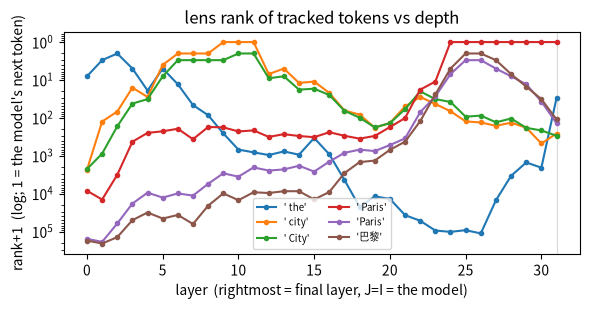

In [10]:
from jlens.hf import from_hf
from jlens.vis import compute_slice
from tabulate import tabulate

from jsteer.demo import lens_slice_ranks, plot_lens_slice

# qualitative: the top tokens each layer points to (generic slot -> specific answer)
PROMPT = "The Eiffel Tower is located in the city of"
lo, mid, hi = jac.layers[0], jac.layers[len(jac.layers) // 2], jac.layers[-1]
for layer in (lo, mid, hi):
    top = jac.lens_topk(model, tok, PROMPT, layer=layer, k=6)
    print(f"L{layer:>2} top-6: {[t for t, _ in top]}")

# quantitative + calibrated, via jlens's own compute_slice (reference machinery):
# sweeps every fitted layer, AUTO-selects tracked tokens (we only pin the answer
# words), and returns full-vocab ranks with the final layer as the J=I model row.
pin = {tok(w, add_special_tokens=False).input_ids[0] for w in (" Paris", " city")}
sd = compute_slice(from_hf(model, tok), jac.lens, PROMPT, top_n=10, max_tracked=6,
                   pinned_token_ids=pin, last_n_tokens=1, mask_display=True)

labels, layers, ranks = lens_slice_ranks(sd)
show = [0, len(layers) // 2, len(layers) - 1]      # low / mid / final(model) columns
tbl = [[labels[j]] + [int(ranks[i, j]) for i in show] for j in range(len(labels))]
hdr = ["token"] + [f"L{layers[i]}" + ("(model)" if i == len(layers) - 1 else "") for i in show]
print("\ntracked (auto-selected):", labels)
print(tabulate(tbl, headers=hdr, tablefmt="github"))
plot_lens_slice(sd, title="lens rank of tracked tokens vs depth");

## Extract once, steer forever

The steering vector is a plain steering-lite `Vector` (safetensors on disk),
so you can save it and reuse it without the Jacobian cache or jsteer at all.

In [11]:
# The vector is a plain steering-lite Vector: save it, reuse it with no Jacobian
# cache and no jsteer at apply time (only the chat template + steering-lite).
from steering_lite import Vector

v.save("../artifacts/happy_joy.safetensors")
v2 = Vector.load("../artifacts/happy_joy.safetensors")

msg = [{"role": "user", "content": "Describe how your week has been going."}]
prompt = tok.apply_chat_template(msg, add_generation_prompt=True, tokenize=False, enable_thinking=True)
enc = tok(prompt, return_tensors="pt").to(model.device)
with v2(model, C=0.5):
    out = model.generate(**enc, max_new_tokens=200, pad_token_id=tok.eos_token_id)
print(tok.decode(out[0][enc.input_ids.shape[1]:], skip_special_tokens=True))

Thinking process:

1. **Analyze the Request:**
*  The user is asking me to describe how my week has been going.
*  I am an AI, so I don't have feelings, a physical life, or a personal week.
*However,I can simulate a happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,happy,
